In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/babies-food-ingredients/food_Ingredients.csv


# Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df = pd.read_csv('/kaggle/input/babies-food-ingredients/food_Ingredients.csv')

In [4]:
df.head(2)

,Unnamed: 0,size,calories_kcal,fats_g,sod_mg,carb_g,fiber_g,sugar_g,protein_g,vitA_g,...,vitK_mcg,vitC_mg,vitB6_mg,copper_mg,carotene_mg,carotene_mcg,cryptoxanthin_mcg,lycopene_mcg,cholesterol_mg,quality
0,0,1.0,21.26,0.20,8.79,4.45,0.0,2.69,0.37,0.0,...,0.17,6.95,0.07,0.02,3.40,1.98,1.13,0.0,0.0,1
1,1,NaN,82.49,0.79,2.26,17.40,0.9,11.85,1.47,33.9,...,2.49,24.63,0.23,0.08,14.69,2.26,9.04,0.0,0.0,0


# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         696 non-null    int64  
 1   size               534 non-null    float64
 2   calories_kcal      696 non-null    float64
 3   fats_g             696 non-null    float64
 4   sod_mg             696 non-null    float64
 5   carb_g             696 non-null    float64
 6   fiber_g            696 non-null    float64
 7   sugar_g            696 non-null    float64
 8   protein_g          696 non-null    float64
 9   vitA_g             696 non-null    float64
 10  calcium_mg         696 non-null    float64
 11  thiamin_mg         696 non-null    float64
 12  zinc_mg            696 non-null    float64
 13  potassium_mg       696 non-null    float64
 14  magnesium_mg       696 non-null    float64
 15  vitE_mg            696 non-null    float64
 16  vitK_mcg           696 non

In [6]:
df.isna().sum()

Unnamed: 0             0
size                 162
calories_kcal          0
fats_g                 0
sod_mg                 0
carb_g                 0
fiber_g                0
sugar_g                0
protein_g              0
vitA_g                 0
calcium_mg             0
thiamin_mg             0
zinc_mg                0
potassium_mg           0
magnesium_mg           0
vitE_mg                0
vitK_mcg               0
vitC_mg                0
vitB6_mg               0
copper_mg              0
carotene_mg            0
carotene_mcg           0
cryptoxanthin_mcg      0
lycopene_mcg           0
cholesterol_mg         0
quality                0
dtype: int64

In [7]:
df['size'].value_counts()

1.00     280
4.00     121
6.00      60
2.50      48
4.50      11
4.25       9
4.20       3
6.25       1
75.00      1
Name: size, dtype: int64

In [8]:
df['size'].fillna(1.0, inplace=True)

In [9]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [10]:
df.duplicated().sum()

117

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.describe()

,size,calories_kcal,fats_g,sod_mg,carb_g,fiber_g,sugar_g,protein_g,vitA_g,calcium_mg,...,vitK_mcg,vitC_mg,vitB6_mg,copper_mg,carotene_mg,carotene_mcg,cryptoxanthin_mcg,lycopene_mcg,cholesterol_mg,quality
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,...,579.000000,579.000000,579.00000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,1.900864,52.948014,0.971952,34.405561,9.818826,1.015872,4.242470,1.729534,1174.669430,18.259775,...,4.607254,11.996062,0.05753,0.046770,574.922124,183.930725,5.783817,79.984162,5.155665,1.644214
std,3.391855,41.081569,1.633813,82.164039,8.917198,1.216370,5.786661,2.466880,2918.940039,25.976180,...,24.406193,23.095345,0.09049,0.056432,1497.983886,595.638248,22.731928,424.812743,12.098856,1.239983
min,1.000000,3.330000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.280000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,15.150000,0.060000,2.640000,2.320000,0.130000,0.280000,0.230000,13.455000,3.425000,...,0.060000,0.480000,0.01000,0.010000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,46.330000,0.270000,9.360000,6.670000,0.450000,1.920000,0.640000,74.800000,8.500000,...,0.530000,2.380000,0.03000,0.030000,19.210000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,1.000000,80.940000,1.020000,27.685000,15.930000,1.700000,4.775000,2.260000,738.300000,23.800000,...,2.490000,13.260000,0.08000,0.060000,307.875000,38.445000,1.630000,0.000000,4.520000,3.000000
max,75.000000,196.940000,10.370000,771.800000,40.260000,6.120000,30.410000,10.930000,26454.400000,240.030000,...,472.080000,178.030000,1.67000,0.640000,12868.800000,6007.680000,332.100000,4377.500000,107.100000,3.000000


# Visualization

<Axes: xlabel='quality', ylabel='count'>

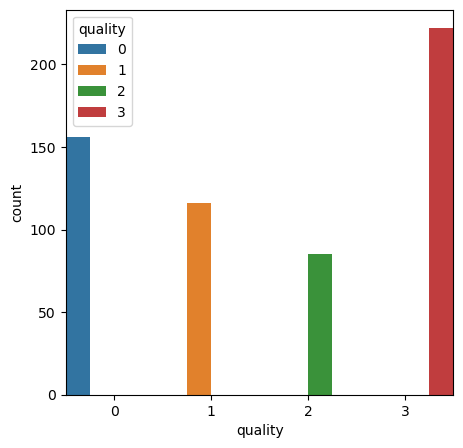

In [13]:
plt.figure(figsize=(5,5))
sns.countplot(x=df.quality, hue=df.quality,width=1)

# Sweetviz 
it will creat a html page of graph
check your output file directory

and download and run

In [14]:
!pip install sweetviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 45.8 MB/s eta 0:00:00


In [15]:
import sweetviz as viz
sviz = viz.analyze(df)
res = sviz.show_html()

/opt/conda/lib/python3.10/site-packages/sweetviz/dataframe_report.py:74: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  all_source_names = [cur_name for cur_name, cur_series in source_df.iteritems()]
/opt/conda/lib/python3.10/site-packages/sweetviz/dataframe_report.py:109: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  filtered_series_names_in_source = [cur_name for cur_name, cur_series in source_df.iteritems()


                                             |          | [  0%]   00:00 -> (? left)

/opt/conda/lib/python3.10/site-packages/sweetviz/series_analyzer_cat.py:28: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for item in category_counts.iteritems():
/opt/conda/lib/python3.10/site-packages/sweetviz/series_analyzer_numeric.py:25: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  stats["mad"] = series.mad()
/opt/conda/lib/python3.10/site-packages/sweetviz/series_analyzer_numeric.py:25: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  stats["mad"] = series.mad()
/opt/conda/lib/python3.10/site-packages/sweetviz/series_analyzer_numeric.py:25: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  st

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


<Axes: >

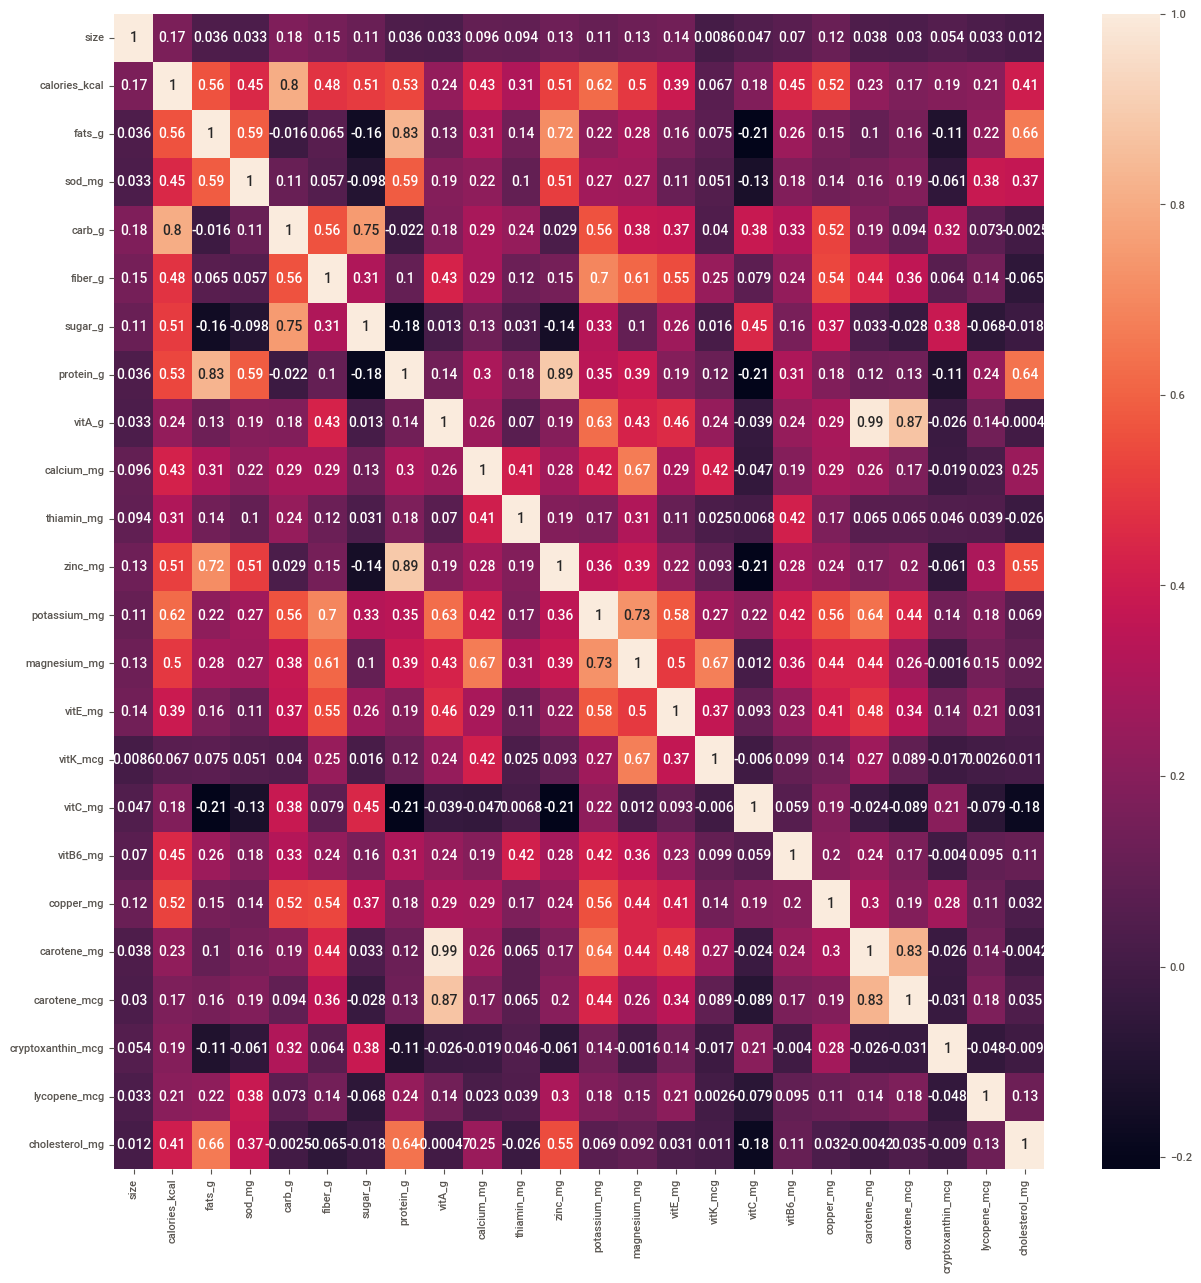

In [16]:
plt.figure(figsize=(15,15))
sns.heatmap(df.drop('quality', axis=1).corr(), annot=True)

In [17]:
x = df.drop('quality', axis=1)
y = df.quality

In [18]:
y.value_counts()

3    222
0    156
1    116
2     85
Name: quality, dtype: int64

# Scaling 

In [19]:
# sc = StandardScaler()
# x = sc.fit_transform(x)
sc = MinMaxScaler()
x = sc.fit_transform(x)


# Splitting

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x,y)

# Smotting 
its used for unbalanced data 

In [21]:
smote = SMOTE()
x_train, y_train = smote.fit_resample(x_train, y_train) 

In [22]:
y_train.value_counts()

1    175
3    175
0    175
2    175
Name: quality, dtype: int64

#  Model

In [23]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)
test_pred = model.predict(x_test)
train_pred = model.predict(x_train)

print('accuracy on test data ')
print(classification_report(y_test, test_pred))

print('accuracy on train data ')
print(classification_report(y_train, train_pred))

accuracy on test data 
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        39
           1       0.95      0.92      0.93        38
           2       0.87      0.95      0.91        21
           3       1.00      1.00      1.00        47

    accuracy                           0.97       145
   macro avg       0.95      0.96      0.96       145
weighted avg       0.97      0.97      0.97       145

accuracy on train data 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       175
           1       1.00      1.00      1.00       175
           2       1.00      1.00      1.00       175
           3       1.00      1.00      1.00       175

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700



In above model we can see ,

its look like overfitting, to overcome this problem 

we apply some hyparameter tunning

# High Parameter Tunning With Grid SearchCV

In [24]:
from sklearn.model_selection import RandomizedSearchCV
 
# Creating the hyperparameter grid
param_dist = {"max_depth": [3,5,100, 30,20, 40,50,200,300, None],
              "max_features": [1,2,3,4,5,6,7,8,9, 10, 11, 20,25,30],
              "min_samples_leaf": [1,2,3,4,5,6,7,8,9, 30, 25,11,21,12,40],
              "criterion": ["gini", "entropy"]}

tree_cv = RandomizedSearchCV(model, param_dist, cv = 15)

In [25]:
tree_cv.fit(x_train, y_train)

RandomizedSearchCV(cv=15, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 100, 30, 20, 40, 50,
                                                      200, 300, None],
                                        'max_features': [1, 2, 3, 4, 5, 6, 7, 8,
                                                         9, 10, 11, 20, 25,
                                                         30],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 30, 25,
                                                             11, 21, 12, 40]})

# best Pamameters

In [26]:
print('best parameters:',tree_cv.best_params_)
print('best score : ', tree_cv.best_score_)

best parameters: {'min_samples_leaf': 8, 'max_features': 30, 'max_depth': 3, 'criterion': 'entropy'}
best score :  0.9613629355535


# Accuracy Afetr tunning

In [27]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(min_samples_leaf=6, max_features=30, max_depth=5, criterion='gini')
model.fit(x_train, y_train)
test_pred = model.predict(x_test)
train_pred = model.predict(x_train)

print('accuracy on test data ')
print(classification_report(y_test, test_pred))

print('accuracy on train data ')
print(classification_report(y_train, train_pred))

accuracy on test data 
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        39
           1       0.94      0.89      0.92        38
           2       0.83      0.95      0.89        21
           3       1.00      1.00      1.00        47

    accuracy                           0.96       145
   macro avg       0.94      0.96      0.95       145
weighted avg       0.96      0.96      0.96       145

accuracy on train data 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       175
           1       0.98      0.93      0.95       175
           2       0.93      0.98      0.96       175
           3       1.00      1.00      1.00       175

    accuracy                           0.98       700
   macro avg       0.98      0.98      0.98       700
weighted avg       0.98      0.98      0.98       700



# Generlized model
looking above accuracy difference between train and test data we can say it's generlized model